In [1]:
%load_ext autoreload
%autoreload 2

import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
assert os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] == "false"

import sys
sys.path.append('../')
sys.path.append('../../')

import ATLAS

import json, pickle
from glob import glob
from tqdm import tqdm

import numpy as np
from matplotlib import pyplot as plt

from functools import partial
import jax.numpy as jnp
import jax.random as jrandom

from ATLAS.utils import jit, jit_method, get_pulsar_timespan
from ATLAS.utils import jagged2padded
from ATLAS.signals.signals_utils import _timing_model_svd, get_fourier_design_matrix

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS

sim_path = '../../datasets/sim_NG15_01'

JAX 64-bit mode automatically enabled successfully.


/home/kyleg/miniforge3/envs/atlas/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from ATLAS.pulsar import load_pulsars

npsrs = 2

par = sorted(glob(sim_path+'/par/*.par'))[:npsrs]
tim = sorted(glob(sim_path+'/tim/*.tim'))[:npsrs]

psrs = load_pulsars(par, tim, use_enterprise=True)

psr = psrs[0]


with open(sim_path+'/injected_params.json', 'r') as f:
    injected_params = json.load(f)

libstempo not installed. PINT or libstempo are required to use par and tim files.
Loading pulsars...:   0%|          | 0/2 [00:00<?, ?it/s]

JAX 64-bit mode automatically enabled successfully.
JAX 64-bit mode automatically enabled successfully.


libstempo not installed. PINT or libstempo are required to use par and tim files.
libstempo not installed. PINT or libstempo are required to use par and tim files.
Loading pulsars...: 100%|██████████| 2/2 [00:25<00:00, 12.81s/it]


## White Noise

In [3]:


class psr_toa_cov:
    def __init__(self, psr, use_backends=True):
        self.psr = psr
        self.use_backends = use_backends

        # Helpful attributes
        self.psr_name = psr.name
        self.n_toas = len(psr.toas)
        self.toaerrs = psr.toaerrs
        
        if self.use_backends:
            backends, B, U_pad, U_mask, V = _get_psr_wn_attributes(psr)

            self.n_epochs = len(U_pad)

            # Matrices needed for computing N 
            self.backends = backends
            self.n_backends = len(backends)
            self.U_pad = U_pad
            self.U_mask = U_mask
            self.B = B # To construct nvec
            self.V = V # To construct jvec

        # M matrix stuffs
        self.Mmat = psr.Mmat
        
        # The prior for the timing model parameters is pseudo-uniform and infinite
        self.Mprior = self.Mmat.shape[1] * jnp.log(1e40) 
        
    @property
    def param_names(self):
        if self.use_backends:
            ef = [f'{self.psr_name}_{b}_efac' for b in self.backends]
            eq = [f'{self.psr_name}_{b}_log10_t2equad' for b in self.backends]
            ec = [f'{self.psr_name}_{b}_log10_ecorr' for b in self.backends]
            return np.array([ef, eq, ec])
        else:
            return []
   
    @jit_method
    def get_helpers(self, params):
        if self.use_backends:
            ef2 = params[0]**2 # (n_backends,)
            eq2 = 10**(2*params[1]) # (n_backends,)
            ec2 = 10**(2*params[2]) # (n_backends,)

            nvec = ef2[self.B] * (self.toaerrs ** 2 + eq2[self.B])
            jvec = ec2[self.V]
            helpers = (nvec, jvec)

        else:
            helpers = (None) # No helpers needed for no backends

        return helpers
    
    @jit(static_argnums=(0,4,5))
    def solve(self, helpers, R, L=None, tm_marg=False, return_logdet=False):
        # Add extra dimensions if needed
        R = R[:,None] if R.ndim == 1 else R # (n_toa, M)
        L = L[:,None] if L is not None and L.ndim == 1 else L # (n_toa, N)

        # Get the solver function
        if tm_marg:
            solver = self._solve_marg
        elif self.use_backends:
            solver = self._solve_backends
        else:
            solver = self._solve_nobackends

        # Solution is N^{-1} R (n_toa, M)
        sol, logdet = solver(helpers, R)

        # Deal with L if provided
        sol = L.T @ sol if L is not None else sol # (N, M)
        
        if return_logdet:
            return sol, logdet
        return sol
    
    def _solve_marg(self, helpers, R):
        # Get the solver function
        solver = self._solve_backends if self.use_backends else self._solve_nobackends

        # N^{-1} R - N^{-1} M (M^T N^{-1} M)^{-1} M^T N^{-1} R
        # Term 1
        NinvR, logdet_N = solver(helpers, R) # (n_toa, M), scalar
        
        # Term 2
        NinvM, _ = solver(helpers, self.Mmat) # (n_toa, n)
        MNinvR = NinvM.T @ R # (n, M)
        MNinvM = NinvM.T @ self.Mmat # (n, n)
        cf = jsl.cho_factor(MNinvM)
        NMMNMMNR = NinvM @ jsl.cho_solve(cf, MNinvR) # (n, M)

        DinvR = NinvR - NMMNMMNR # (n_toa, M)

        logdet_D = logdet_N + 2*jnp.sum(jnp.log(jnp.diag(cf[0]))) + self.Mprior
        return DinvR, logdet_D
        
    def _solve_nobackends(self, helpers, R):
        nvec = self.toaerrs**2 # (n_toa,)

        Ninv = 1/nvec # (n_toa,)
        NinvR = Ninv[:,None] * R # (n_toa, M)

        logdet = jnp.sum(jnp.log(nvec))
        return NinvR, logdet
    
    def _solve_backends(self, helpers, R):
        # Unpack helpers, and easy notation
        nvec, jvec = helpers # (n_toa,), (n_epochs,)
        p, m = self.U_pad, self.U_mask # (b, x), (b, x)
        
        Ainv = 1 / nvec # (n_toa,)

        # Diagonal bit
        NinvR = Ainv[:, None] * R  # (n_toa, M)

        # Per-epoch bit: b is number of epochs, x is max epoch size
        Ainv_b = Ainv[p] * m  # (b, x)
        AinvR_b = jnp.sum(NinvR[p, :] * m[:, :, None], axis=1)  # (b, M)

        # Denominator of the per-epoch sherman-morrison formula
        den = 1.0 + jnp.sum(Ainv_b, axis=1) * jvec  # (b,)

        # Correction term for the per-epoch sherman-morrison formula
        cor = (Ainv_b[:,:,None]*jvec[:,None,None]*AinvR_b[:,None,:]) / den[:,None,None]  # (b, x, M)

        # Apply the correction term to NinvR
        NinvR = NinvR.at[p].add(-cor)  # (n_toa, M) 

        logdet = jnp.sum(jnp.log(nvec)) + jnp.sum(jnp.log(den))
        return NinvR, logdet


# WN helper functions

def _get_psr_wn_attributes(psr):
    """Get the helper matrices for computing the white noise covariance matrix

    This function computes several helper quantities for computing the N matrix
    and its inverse solutions for a given pulsar. These include:
    - backends: (N_backends) an ordered list of unique backend names for this pulsar
    - B: (N_toa) an array of backend indices for each toa (i.e. which backend each toa belongs to)
    - U_pad: (N_epoch, max_epoch_size) a padded array of toa indices for each epoch [padded with -1]
    - U_mask: (N_epoch, max_epoch_size) a boolean mask indicating which elements of U_pad are valid
    - V: (N_epoch) an array of backend indices for each epoch (i.e. which backend each epoch belongs to)

    The user supplies a pulsar object which must contain the following attributes:
    - toas: (N_toa) array of time of arrivals for this pulsar
    - backend_flags: (N_toa) array of backend names for each toa

    Parameters
    ----------
    psr : object
        The pulsar object to compute the helper arrays/matrices for [check description]
    
    Returns
    -------
    out : tuple
        A tuple containing the following helper arrays/matrices for computing the white noise covariance matrix:
        - backends: (N_backends) an ordered tuple of unique backend names for this pulsar
        - B: (N_toa) an array of backend indices for each toa (i.e. which backend each toa belongs to)
        - U_pad: (N_epoch, max_epoch_size) a padded array of toa indices for each epoch [padded with -1]
        - U_mask: (N_epoch, max_epoch_size) a boolean mask indicating which elements of U_pad are valid
        - V: (N_epoch) an array of backend indices for each epoch (i.e. which backend each epoch belongs to)
    """
    # Use numpy for most of this
    import numpy as np

    # The array of backends and an array which indicates which backend each toa belongs to
    backends, B = np.unique(psr.backend_flags, return_inverse=True) # [n_backends], [n_toas]
    backends = tuple(backends) # Convert to tuple

    # The indices of toas for each backend (i.e. which toas belong to each backend)
    backend_idx = [np.where(B == i)[0] for i in range(len(backends))]

    U = [] # We don't know how many toas will be in each epoch!
    V = [] # We don't know how many epochs there will be!
    for i in range(len(backends)):
        # Get this backend's toas
        toas = psr.toas[backend_idx[i]]
        isort = np.argsort(toas)
        sort_toas = toas[isort]

        # Find indices where adjacent toas are separated by >= dt (different epochs)
        breaks = np.where(np.diff(sort_toas) >= 1.0)[0] + 1 # (plus 1 since diff)
        epochs = np.split(isort, breaks) # List of arrays of indices for each epoch (in backend indexing)

        # Convert to sorted jax arrays and drop single-toa epochs (in backend indexing)
        epoch_idx = [np.sort(jnp.array(epoch, dtype=int))
                     for epoch in epochs if len(epoch) > 1]

        # Map backend indices to global indices through B[i]
        epochs = [backend_idx[i][e] for e in epoch_idx] 

        U.extend(epochs) # Add these epochs to U
        V.extend([i]*len(epochs)) # Add the backend index for these epochs to V

    # U is a list of arrays of toa indices for each epoch
    # we need to convert this to a padded array for fast einsum computations
    U_pad, U_mask = jagged2padded(U, pad_value=-1) # [n_epochs, max_epoch_size], [n_epochs, max_epoch_size]
    U_pad, U_mask = jnp.array(U_pad, dtype=int), jnp.array(U_mask, dtype=bool)

    # V is a list of backend indices for each epoch (i.e. which backend each epoch belongs to)
    V = jnp.array(V, dtype=int)
    # B is an array of backend indices for each toa (i.e. which backend each toa belongs to)
    B = jnp.array(B, dtype=int)

    out = (backends, B, U_pad, U_mask, V)
    return out



In [4]:
N = psr_toa_cov(psr)
r = psr.residuals

def model():
    ef = numpyro.sample('EFAC', dist.Uniform(0, 10).expand([N.n_backends]))
    eq = numpyro.sample('EQUAD', dist.Uniform(-10, -1).expand([N.n_backends]))
    ec = numpyro.sample('ECORR', dist.Uniform(-10, -1).expand([N.n_backends]))
    pars = jnp.stack([ef, eq, ec]) # ([efac, equad, ecorr], n_backends)

    helpers = N.get_helpers(pars)

    rNr, logdetN = N.solve(helpers, r, r, return_logdet=True)
    lnlike = -0.5*(rNr + logdetN)

    numpyro.factor('lnlike', lnlike)

x0 = {
    "EFAC": jnp.ones(N.n_backends),
    "EQUAD": jnp.ones(N.n_backends)*-6,
    "ECORR": jnp.ones(N.n_backends)*-6 }

kernel = NUTS(model=model, max_tree_depth=10)

mcmc = MCMC(sampler=kernel, num_warmup=500, num_samples=2000)

mcmc.run(jrandom.PRNGKey(0), init_params=x0)
samples = mcmc.get_samples()


sample: 100%|██████████| 2500/2500 [00:28<00:00, 86.96it/s, 7 steps of size 1.55e-01. acc. prob=0.86]  


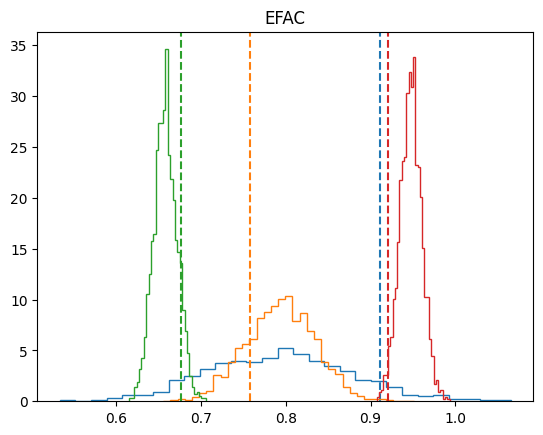

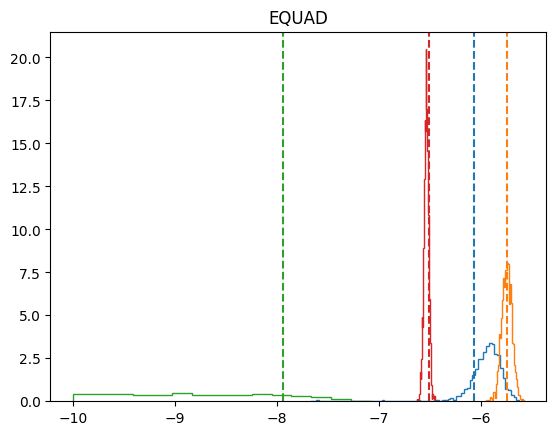

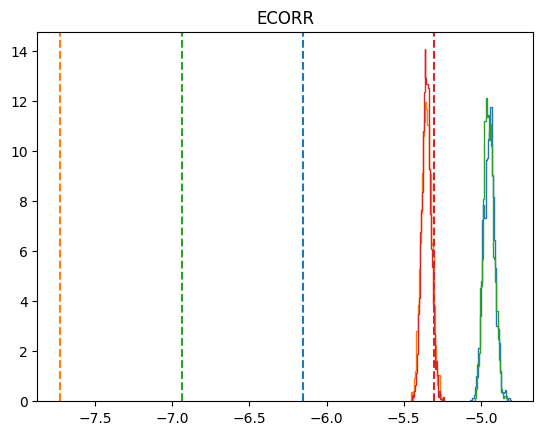

In [5]:
for i in range(N.n_backends):
    backend = N.backends[i]
    plt.hist(samples['EFAC'][:, i], density=True, bins='auto', color=f'C{i}', histtype='step')
    plt.axvline(injected_params[f'{psr.name}_{backend}_efac'], linestyle='--', color=f'C{i}')
plt.title('EFAC')
plt.show()

for i in range(N.n_backends):
    backend = N.backends[i]
    plt.hist(samples['EQUAD'][:, i], density=True, bins='auto', color=f'C{i}', histtype='step')
    plt.axvline(injected_params[f'{psr.name}_{backend}_equad'], linestyle='--', color=f'C{i}')
plt.title('EQUAD')
plt.show()

for i in range(N.n_backends):
    backend = N.backends[i]
    plt.hist(samples['ECORR'][:, i], density=True, bins='auto', color=f'C{i}', histtype='step')
    plt.axvline(injected_params[f'{psr.name}_{backend}_ecorr'], linestyle='--', color=f'C{i}')
plt.title('ECORR')
plt.show()

## Timing model

In [6]:
binary_priors = {
    'PB':       dist.Uniform(0.05, 500),        # Orbital period (days)
    'PBDOT':    dist.Uniform(-1e-10, 1e-10),    # Time derivative of orbital period
    'A1':       dist.Uniform(0, 150),           # Projected semi-major axis (light-seconds)
    'A1DOT':    dist.Uniform(-1e-10, 1e-10),    # Time derivative of A1
#    '_DT0':     dist.Uniform(-1, 1),            # delta of T0 (MJD) 
#    'T0':       None, # Use _DT0 to derive      # Epoch of periastron passage (MJD)
#    '_DTASC':   dist.Uniform(-1, 1),            # delta of TASC (MJD)
#    'TASC':     None, # Use _DTASC to derive    # Epoch of ascending node passage (MJD)
    'ECC':      dist.Uniform(0, 1),             # Orbital eccentricity
    'EDOT':     dist.Uniform(-1e-10, 0),        # Time derivative of eccentricity
    'OM':       dist.Uniform(-360, 360),        # Longitude of periastron (deg)
    'OMDOT':    dist.Uniform(-3, 3),            # Time derivative of OM
    'EPS1':     dist.Uniform(-1, 1),            # Laplace-Lagrange parameter e*sin(omega)
    'EPS2':     dist.Uniform(-1, 1),            # Laplace-Lagrange parameter e*cos(omega)
    '_COSI':    dist.Uniform(0, 1),             # cos(inclination) [Used to derive SINI]
    'SINI':     None, # Use _COSI to derive     # sin(inclination)
    'M2':       dist.TruncatedNormal( loc=0.214, scale=0.25, 
                low=0, high=1),                 # Companion mass (solar masses)
    'KIN':      dist.Uniform(0, 360),           # Inclination angle (deg), used by DDK
    'KOM':      dist.Uniform(-180, 180),        # Longitude of ascending node (deg), used by DDK
    'H3':       dist.Uniform(-1e-6, 1e-6),      # Orthometric Shapiro delay amplitude
    'FB0':      dist.Uniform(0, 1),             # Orbital frequency and derivatives (ELL1)
    'FB1':      dist.Uniform(-1e-15, 1e-15),     
    'FB2':      dist.Uniform(-1e-15, 1e-15),
    'FB3':      dist.Uniform(-1e-15, 1e-15),
    'FB4':      dist.Uniform(-1e-15, 1e-15),
    'FB5':      dist.Uniform(-1e-15, 1e-15),
}

class psr_timingmodel:
    def __init__(self, psr, inflate_z=1e5):
        self.psr = psr
        self.name = psr.name
        self.residuals = psr.residuals
        self.M = psr.Mmat # (n_toas, npar)
        self.M_labels = psr.Mmat_labels # Labels of the columns in the M matrix (npar,)
        self.M_par = self.M.shape[1] # number of parameters in the M matrix
        self.U = _timing_model_svd(self.M) # Use TM svd

        # Fit parameter values and uncertainties with an added offset column
        self.hat = jnp.insert(psr.fit_param_values, 0, 0) # Add offset column (npar,)
        self.sigma = jnp.insert(psr.fit_param_uncertainties, 0, 1) # Add offset column (npar,)
        self.inflate_z = inflate_z # How much to scale the prior on the sigma

        # Make boolean masks of binary and other parameters in the M matrix
        self.Mb_idx = jnp.array([label in binary_priors for label in self.M_labels])
        self.Mo_idx = ~self.Mb_idx

        self.Mb = self.M[:, self.Mb_idx] # Binary parameters in the M matrix
        self.Mb_labels = [label for label in self.M_labels if label in binary_priors] # Labels of the binary parameters in the M matrix
        self.Mb_par = self.Mb.shape[1] # number of binary parameters in the M matrix
        self.Ub = self.U[:, self.Mb_idx] # SVD of binary parameters in the M matrix

        self.Mo = self.M[:, self.Mo_idx] # Other parameters in the M matrix
        self.Mo_labels = [label for label in self.M_labels if label not in binary_priors] # Labels of the other parameters in the M matrix
        self.Mo_par = self.Mo.shape[1] # number of other parameters in the M matrix
        self.Uo = self.U[:, self.Mo_idx] # SVD of other parameters in the M matrix

    def sample_prior(self):
        z_dist = dist.Normal(0, self.inflate_z).expand((self.M_par,))
        z = numpyro.sample(f'z_tm_{self.name}', z_dist)
        # Convert to epsilon
        epsilon = z*self.sigma
        return epsilon

    def compute_r(self, epsilon, use_svd=False):
        # Given epsilons, just multiply by the M matrix to get the timing residuals
        if use_svd:
            return self.residuals - self.U @ epsilon
        else:
            return self.residuals - self.M @ epsilon

    def init_params(self):
        x0 = {f'z_tm_{self.name}': jnp.zeros(self.M_par)}
        return x0

    def sample_prior_split(self):
        # Non-binary parameters first
        z_dist = dist.Normal(0, self.inflate_z).expand((self.Mo_par,))
        z = numpyro.sample(f'z_tm_mo_{self.name}', z_dist)
        epsilon_o = z*self.sigma[self.Mo_idx]

        # Binary parameters next
        epsilon_b = jnp.zeros(self.Mb_par) # Initialize binary parameter epsilons
        for i, label in enumerate(self.Mb_labels):
            # Most parameters have defined priors except for SINI
            if 'SINI' in label:
                # Sample in uniform COSI instead
                cosi_dist = dist.Uniform(0, 1)
                cosi = numpyro.sample(f'{self.name}_COSI', cosi_dist)
                v = jnp.sqrt(1 - cosi**2)
                numpyro.deterministic(f'{self.name}_SINI', v)
                dv = v - self.hat[self.Mb_idx][i]
                epsilon_b = epsilon_b.at[i].set(dv)
            else:
                # For other binary parameters, just use the prior
                prior_dist = binary_priors[label]
                v = numpyro.sample(f'{self.name}_{label}', prior_dist)
                dv = v - self.hat[self.Mb_idx][i]
                epsilon_b = epsilon_b.at[i].set(dv)

        return epsilon_o, epsilon_b

    def compute_r_split(self, epsilon_o, epsilon_b, use_svd=False):
        if use_svd:
            r = self.residuals - self.Uo @ epsilon_o - self.Mb @ epsilon_b
        else:
            r = self.residuals - self.Mo @ epsilon_o - self.Mb @ epsilon_b
        return r

    def init_params_split(self):
        x0 = {f'z_tm_mo_{self.name}': jnp.zeros(self.Mo_par)}
        for label in self.Mb_labels:
            x0[f'{self.name}_{label}'] = 0.0
        return x0



In [7]:
N = psr_toa_cov(psr)
TM = psr_timingmodel(psr, inflate_z=1e5)

def model():
    epsilon = TM.sample_prior()
    r = TM.compute_r(epsilon, use_svd=True)
    numpyro.deterministic('r', r)

    ef = numpyro.sample('EFAC', dist.Uniform(0, 10).expand([N.n_backends]))
    eq = numpyro.sample('EQUAD', dist.Uniform(-10, -1).expand([N.n_backends]))
    ec = numpyro.sample('ECORR', dist.Uniform(-10, -1).expand([N.n_backends]))
    pars = jnp.stack([ef, eq, ec]) # ([efac, equad, ecorr], n_backends)

    helpers = N.get_helpers(pars)

    rNr, logdetN = N.solve(helpers, r, r, return_logdet=True)
    lnlike = -0.5*(rNr + logdetN)

    numpyro.factor('lnlike', lnlike)


x0 = TM.init_params()
x0.update({
    "EFAC": jnp.ones(N.n_backends),
    "EQUAD": jnp.ones(N.n_backends)*-6,
    "ECORR": jnp.ones(N.n_backends)*-6 })


kernel = NUTS(model=model, max_tree_depth=10)

mcmc = MCMC(sampler=kernel, num_warmup=500,
            num_samples=2000, num_chains=1)

mcmc.run(jrandom.PRNGKey(1), init_params=x0)
samples = mcmc.get_samples()


sample: 100%|██████████| 2500/2500 [09:44<00:00,  4.28it/s, 33 steps of size 3.27e-04. acc. prob=0.52]  


PMELAT


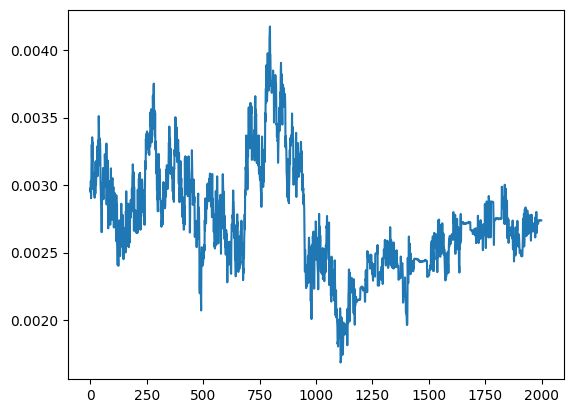

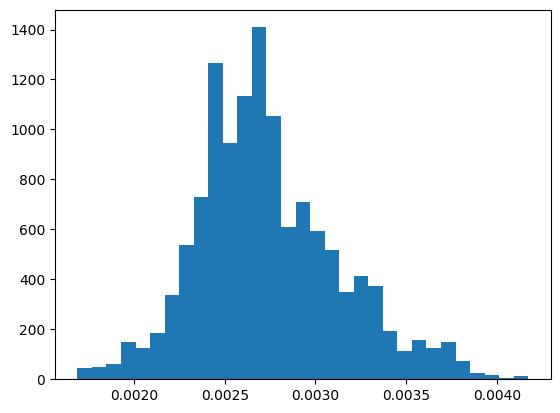

In [8]:
i = 5
print(TM.M_labels[i])
plt.plot(samples['z_tm_B1855+09'][:,i])
plt.show()
plt.hist(samples['z_tm_B1855+09'][:,i], bins='auto', density=True);
plt.show()

### Split timing

In [ ]:
N = psr_toa_cov(psr)
TM = psr_timingmodel(psr, inflate_z=1e5)


def model():
    epsilon_o, epsilon_b = TM.sample_prior_split()
    r = TM.compute_r_split(epsilon_o, epsilon_b, use_svd=True)
    numpyro.deterministic('r', r)

    ef = numpyro.sample('EFAC', dist.Uniform(0, 10).expand([N.n_backends]))
    eq = numpyro.sample('EQUAD', dist.Uniform(-10, -1).expand([N.n_backends]))
    ec = numpyro.sample('ECORR', dist.Uniform(-10, -1).expand([N.n_backends]))
    pars = jnp.stack([ef, eq, ec]) # ([efac, equad, ecorr], n_backends)

    helpers = N.get_helpers(pars)

    rNr, logdetN = N.solve(helpers, r, r, return_logdet=True)
    lnlike = -0.5*(rNr + logdetN)

    numpyro.factor('lnlike', lnlike)


x0 = TM.init_params_split()
x0.update({"EFAC":jnp.ones(N.n_backends),
               "EQUAD":jnp.ones(N.n_backends)*-6,
               "ECORR":jnp.ones(N.n_backends)*-6})

kernel = NUTS(model=model, max_tree_depth=10)

mcmc = MCMC(sampler=kernel, num_warmup=1000, num_samples=2000)

mcmc.run(jrandom.PRNGKey(3))
samples = mcmc.get_samples()


sample:  64%|██████▍   | 1924/3000 [26:08<27:58,  1.56s/it, 1023 steps of size 9.29e-05. acc. prob=0.82]  

A1


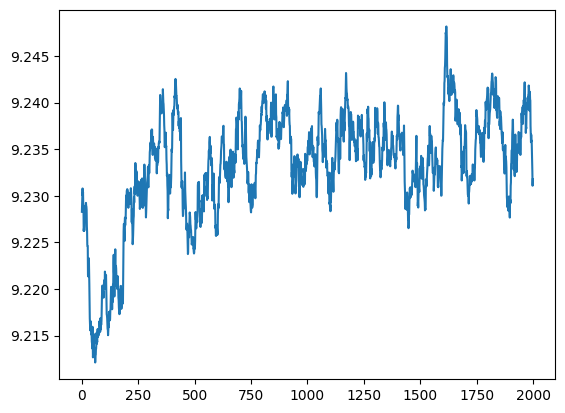

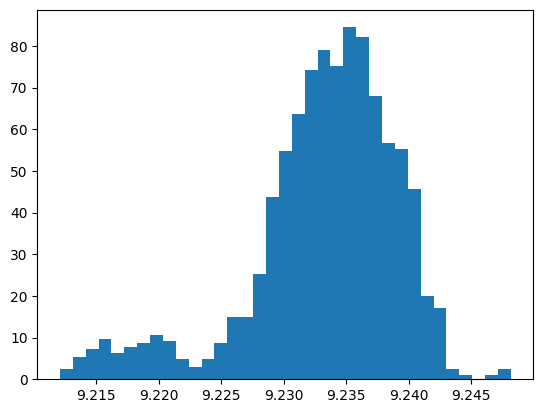

In [ ]:
print('A1')
plt.plot(samples['B1855+09_A1'][:]);
plt.show()
plt.hist(samples['B1855+09_A1'][:], bins='auto', density=True);
plt.show()

Offset


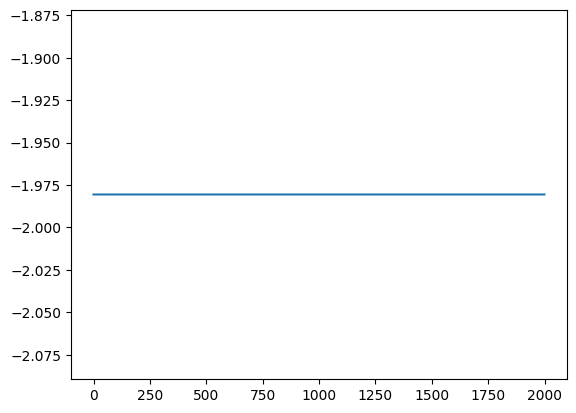

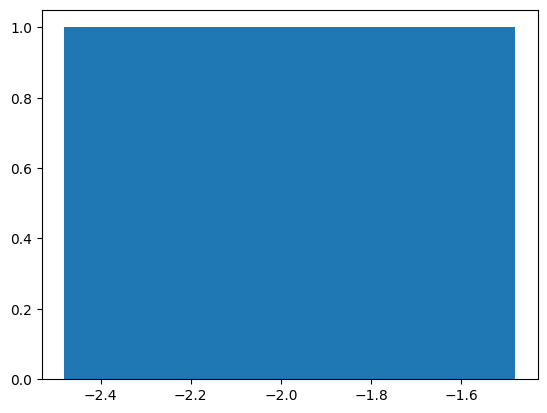

In [ ]:
i = 0
print(TM.M_labels[i])
plt.plot(samples['z_tm_mo_B1855+09'][:,i]);
plt.show()
plt.hist(samples['z_tm_mo_B1855+09'][:,i], bins='auto', density=True);
plt.show()